Project 4
CIVI 202 
Group members: Fatima Davila, Harrison Drake, Michael Mccarthy

first step is to import packages pandas for reading datasets, geopandas for plotting maps, matplotlib also for plotting, contextily for data visualization and seaborn for plotting.

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import seaborn as sns
plt.style.use("seaborn-v0_8")

Define nri by using geopandas function "read_file" to read the shapefile

In [44]:
nri = gpd.read_file("NRI_Shapefile_CensusTracts.shp")

Define ia_svi and sd_svi with pandas to read the csv files for each state we will be analyzing

In [45]:
ia_svi = pd.read_csv("Iowa (1).csv")
sd_svi = pd.read_csv("SouthDakota.csv")

This section of code converts the "TRACTSFIPS" or "FIPS" into a string so it can be used to merge the existing data frames cleanly for analysis.

In [46]:
nri["TRACT"] = nri["TRACTFIPS"].astype(str).str.zfill(11)
ia_svi["TRACT"] = ia_svi["FIPS"].astype(str).str.zfill(11)
sd_svi["TRACT"] = sd_svi["FIPS"].astype(str).str.zfill(11)

Below we created a dataframe copy for the specific states used in the analysis.

In [47]:
ia_nri = nri[nri["STATEABBRV"] == "IA"].copy()
sd_nri = nri[nri["STATEABBRV"] == "SD"].copy()

We merged the two datasets we had for Iowa to be able to have access to all the data at the same time. We are merging them on "TRACT" do to that being a common identifier on each dataset.

In [48]:
ia_merged = ia_nri.merge(
    ia_svi,
    on="TRACT",
    how="left",
    suffixes=("_nri", "_svi")
)


We merged the two datasets we had for South Dakota to be able to have access to all the data at the same time.

In [49]:
sd_merged = sd_nri.merge(
    ia_svi,
    on="TRACT",
    how="left",
    suffixes=("_nri", "_svi")
)

Below we are getting a confirmation of all the tracts that survived the merge to be able to continue on.

In [50]:
ia_merged["TRACT"].nunique(), ia_nri["TRACT"].nunique()
sd_merged["TRACT"].nunique(), sd_nri["TRACT"].nunique()

(242, 242)

Below we are converting the map dataframes to a specific web map projection.

In [51]:
ia_merged = ia_merged.to_crs("EPSG:3857")
sd_merged = sd_merged.to_crs("EPSG:3857")

We now clean the data to replace the missing numeric values in each state's merged dataframe with that same dataframe’s median for each numeric column. 

In [71]:
ia_cleaned = ia_merged.fillna(ia_merged.median(numeric_only=True))
sd_cleaned = sd_merged.fillna(sd_merged.median(numeric_only=True))

Below we are computing the product of the frequency of a specific event and the estimated annual loss divided by the population of that specific tract.

In [53]:
ia_cleaned['risk_lvl_tnd_ia'] = (ia_cleaned['TRND_AFREQ'] * ia_cleaned['TRND_EALB']) / ia_cleaned['POPULATION']

C:\Users\fatim\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


Below we are using list comprehensions to search through all column names in ia_cleaned and return only the ones containing "SVI" or "TRND", so we can quickly see which columns are related to social vulnerability and trend data.

In [54]:
[col for col in ia_cleaned.columns if "SVI" in col.upper()]
[col for col in ia_cleaned.columns if "TRND" in col.upper()]

['TRND_EVNTS',
 'TRND_AFREQ',
 'TRND_EXP_A',
 'TRND_EXPB',
 'TRND_EXPP',
 'TRND_EXPPE',
 'TRND_EXPA',
 'TRND_EXPT',
 'TRND_HLRB',
 'TRND_HLRP',
 'TRND_HLRA',
 'TRND_HLRR',
 'TRND_EALB',
 'TRND_EALP',
 'TRND_EALPE',
 'TRND_EALA',
 'TRND_EALT',
 'TRND_EALS',
 'TRND_EALR',
 'TRND_ALRB',
 'TRND_ALRP',
 'TRND_ALRA',
 'TRND_ALR_N',
 'TRND_RISKV',
 'TRND_RISKS',
 'TRND_RISKR']

Here we are creating a new column called "Scoring system IA trnd" where we multiply the first column by 0.45 to get expected loss, the third colum multiplied by 0.20 will show annualized loss. This whol equation will show us how much each factor contributes to a tracts tornado risk score.

In [70]:
ia_cleaned['scoring_system_ia_trnd'] = ((ia_cleaned['TRND_EALA'] * 0.45) + (ia_cleaned['SOVI_SCORE'] * 0.35) + (ia_cleaned['TRND_ALRA'] * 0.20))
ia_cleaned

,NRI_ID,STATE_nri,STATEABBRV,STATEFIPS,COUNTY_nri,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,risk_lvl_tnd_ia,scoring_system_ia_trnd,risk_lvl_hl_ia
0,T19001960100,Iowa,IA,19,Adair,County,001,19001,19001960100,19001960100,...,0.9,0.0,0.9,1.1,0.8,0.0,0.9,32.307722,1378.506398,672.110159
1,T19001960200,Iowa,IA,19,Adair,County,001,19001,19001960200,19001960200,...,1.4,0.7,1.0,0.7,0.8,1.5,1.9,39.774422,1468.387181,877.500773
2,T19001960300,Iowa,IA,19,Adair,County,001,19001,19001960300,19001960300,...,0.8,0.0,0.8,2.6,1.2,0.8,1.1,2.931752,208.909451,429.948852
3,T19003950100,Iowa,IA,19,Adams,County,003,19003,19003950100,19003950100,...,1.5,0.0,1.5,2.7,1.8,0.1,0.2,36.872353,1276.928216,423.113681
4,T19003950200,Iowa,IA,19,Adams,County,003,19003,19003950200,19003950200,...,1.1,0.0,1.2,3.2,1.5,0.0,1.2,7.357628,310.684570,364.911212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,T19197680100,Iowa,IA,19,Wright,County,197,19197,19197680100,19197680100,...,0.7,0.0,0.7,1.3,1.4,0.0,0.7,15.012960,1097.009626,107.271754
892,T19197680200,Iowa,IA,19,Wright,County,197,19197,19197680200,19197680200,...,1.2,0.0,1.6,1.8,2.0,0.3,0.4,16.251819,629.508567,146.298869
893,T19197680300,Iowa,IA,19,Wright,County,197,19197,19197680300,19197680300,...,0.8,0.0,0.8,0.9,1.0,2.8,3.2,8.601299,356.197894,128.640843
894,T19197680400,Iowa,IA,19,Wright,County,197,19197,19197680400,19197680400,...,2.1,0.0,2.1,1.0,1.7,1.1,1.2,19.496553,892.017127,163.641507


This line of code is to compute the product of the frequency of a specific event and the estimated annual loss divided by the population of that specific tract.

In [56]:
sd_cleaned['risk_lvl_tnd_sd'] = (sd_cleaned['TRND_AFREQ'] * sd_cleaned['TRND_EALB']) / sd_cleaned['POPULATION']
sd_cleaned

C:\Users\fatim\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


,NRI_ID,STATE_nri,STATEABBRV,STATEFIPS,COUNTY_nri,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,risk_lvl_tnd_sd
0,T46003973600,South Dakota,SD,46,Aurora,County,003,46003,46003973600,46003973600,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,53.813464
1,T46005956600,South Dakota,SD,46,Beadle,County,005,46005,46005956600,46005956600,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,47.544337
2,T46005956700,South Dakota,SD,46,Beadle,County,005,46005,46005956700,46005956700,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,34.132980
3,T46005956800,South Dakota,SD,46,Beadle,County,005,46005,46005956800,46005956800,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,1.499130
4,T46005956900,South Dakota,SD,46,Beadle,County,005,46005,46005956900,46005956900,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,0.035503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,T46135966200,South Dakota,SD,46,Yankton,County,135,46135,46135966200,46135966200,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,1.592720
238,T46135966301,South Dakota,SD,46,Yankton,County,135,46135,46135966301,46135966301,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,3.259376
239,T46135966302,South Dakota,SD,46,Yankton,County,135,46135,46135966302,46135966302,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,0.235231
240,T46135966400,South Dakota,SD,46,Yankton,County,135,46135,46135966400,46135966400,...,1.1,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,45.497988


This line of code is to compute the product of the frequency of a specific event and the estimated annual loss divided by the population of that specific tract.

In [57]:
ia_cleaned['risk_lvl_hl_ia'] = (ia_cleaned['HAIL_AFREQ'] * ia_cleaned['HAIL_EALB']) / ia_cleaned['POPULATION']
ia_cleaned.tail(2)

C:\Users\fatim\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


,NRI_ID,STATE_nri,STATEABBRV,STATEFIPS,COUNTY_nri,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,risk_lvl_tnd_ia,scoring_system_ia_trnd,risk_lvl_hl_ia
0,T19001960100,Iowa,IA,19,Adair,County,001,19001,19001960100,19001960100,...,0.9,0.0,0.9,1.1,0.8,0.0,0.9,32.307722,1378.506398,672.110159
1,T19001960200,Iowa,IA,19,Adair,County,001,19001,19001960200,19001960200,...,1.4,0.7,1.0,0.7,0.8,1.5,1.9,39.774422,1468.387181,877.500773
2,T19001960300,Iowa,IA,19,Adair,County,001,19001,19001960300,19001960300,...,0.8,0.0,0.8,2.6,1.2,0.8,1.1,2.931752,208.909451,429.948852
3,T19003950100,Iowa,IA,19,Adams,County,003,19003,19003950100,19003950100,...,1.5,0.0,1.5,2.7,1.8,0.1,0.2,36.872353,1276.928216,423.113681
4,T19003950200,Iowa,IA,19,Adams,County,003,19003,19003950200,19003950200,...,1.1,0.0,1.2,3.2,1.5,0.0,1.2,7.357628,310.684570,364.911212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,T19197680100,Iowa,IA,19,Wright,County,197,19197,19197680100,19197680100,...,0.7,0.0,0.7,1.3,1.4,0.0,0.7,15.012960,1097.009626,107.271754
892,T19197680200,Iowa,IA,19,Wright,County,197,19197,19197680200,19197680200,...,1.2,0.0,1.6,1.8,2.0,0.3,0.4,16.251819,629.508567,146.298869
893,T19197680300,Iowa,IA,19,Wright,County,197,19197,19197680300,19197680300,...,0.8,0.0,0.8,0.9,1.0,2.8,3.2,8.601299,356.197894,128.640843
894,T19197680400,Iowa,IA,19,Wright,County,197,19197,19197680400,19197680400,...,2.1,0.0,2.1,1.0,1.7,1.1,1.2,19.496553,892.017127,163.641507


This line of code is to compute the product of the frequency of a specific event and the estimated annual loss divided by the population of that specific tract.

In [58]:
sd_cleaned['risk_lvl_hl_sd'] = (sd_cleaned['HAIL_AFREQ'] * sd_cleaned['HAIL_EALB']) / sd_cleaned['POPULATION']
sd_cleaned

C:\Users\fatim\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


,NRI_ID,STATE_nri,STATEABBRV,STATEFIPS,COUNTY_nri,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,risk_lvl_tnd_sd,risk_lvl_hl_sd
0,T46003973600,South Dakota,SD,46,Aurora,County,003,46003,46003973600,46003973600,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,53.813464,167.720305
1,T46005956600,South Dakota,SD,46,Beadle,County,005,46005,46005956600,46005956600,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,47.544337,3.789652
2,T46005956700,South Dakota,SD,46,Beadle,County,005,46005,46005956700,46005956700,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,34.132980,2.539967
3,T46005956800,South Dakota,SD,46,Beadle,County,005,46005,46005956800,46005956800,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,1.499130,2.319547
4,T46005956900,South Dakota,SD,46,Beadle,County,005,46005,46005956900,46005956900,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,0.035503,1.035207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,T46135966200,South Dakota,SD,46,Yankton,County,135,46135,46135966200,46135966200,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,1.592720,458.395919
238,T46135966301,South Dakota,SD,46,Yankton,County,135,46135,46135966301,46135966301,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,3.259376,514.488804
239,T46135966302,South Dakota,SD,46,Yankton,County,135,46135,46135966302,46135966302,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,0.235231,385.666461
240,T46135966400,South Dakota,SD,46,Yankton,County,135,46135,46135966400,46135966400,...,0.0,0.7,0.0,0.7,2.4,1.8,0.0,0.7,45.497988,567.733576


Below we are establishes a rating order to be used when plotting the map for the specific risk score maps the numbers that are associated with the levels are code for a color scheme.

In [59]:
rating_order = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]
rating_colors = {
    "Very Low": "#2166ac",
    "Relatively Low": "#67a9cf",
    "Relatively Moderate": "#fddbc7",
    "Relatively High": "#ef8a62",
    "Very High": "#b2182b",
}

Below we are creating a tool that serves as the template for all other maps to be plotted so that only the columns and sick equations have to be imput to change the type of disaster and state

In [60]:
def plot_map(gdf, column, cmap="RdYlBu_r", title=None, figsize=(12, 10)):
    fig, ax = plt.subplots(figsize=figsize)

    gdf.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        legend=True,
        linewidth=0.2,
        edgecolor="black"
        )

    ax.set_axis_off()
    ax.set_title(title or column, fontsize=16)
    plt.show()


This section of code utilises the map plot tool to plot the tornado risks based on the origional scoring metric for the state of IA for comparison. 

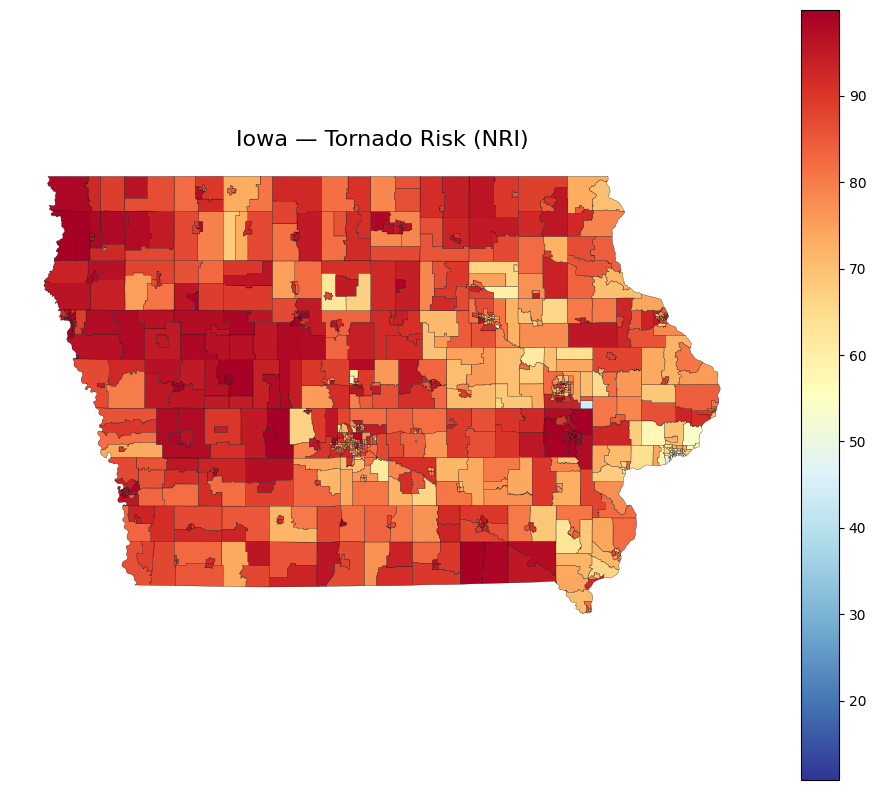

In [66]:
plot_map(
    ia_cleaned,
    column='TRND_RISKS',
    cmap="RdYlBu_r",
    title="Iowa — Tornado Risk (NRI)"
)

This section of code utilises the map plot tool to plot the tornado risks based on the scoring metric we created for the state of IA for comparison.

C:\Users\fatim\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


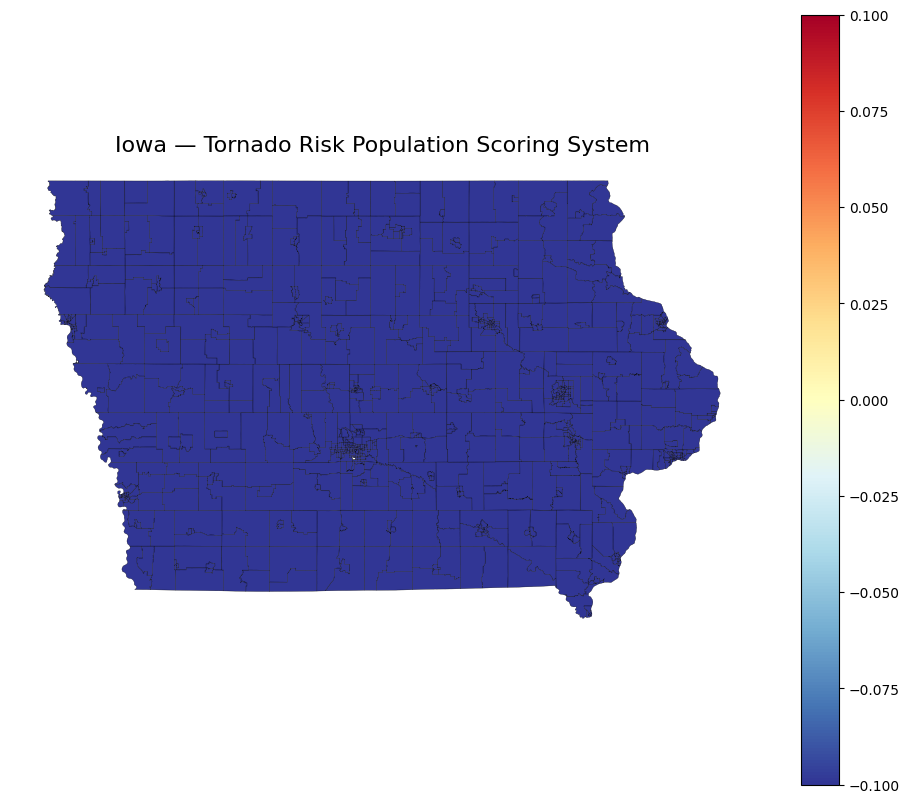

In [67]:
plot_map(
    ia_cleaned,
    column='risk_lvl_tnd_ia',
    cmap="RdYlBu_r",
    title="Iowa — Tornado Risk Population Scoring System"
)


This section of code utilises the map plot tool to plot the tornado risks based on the scoring metric we created for the state of South Dakota for comparison.

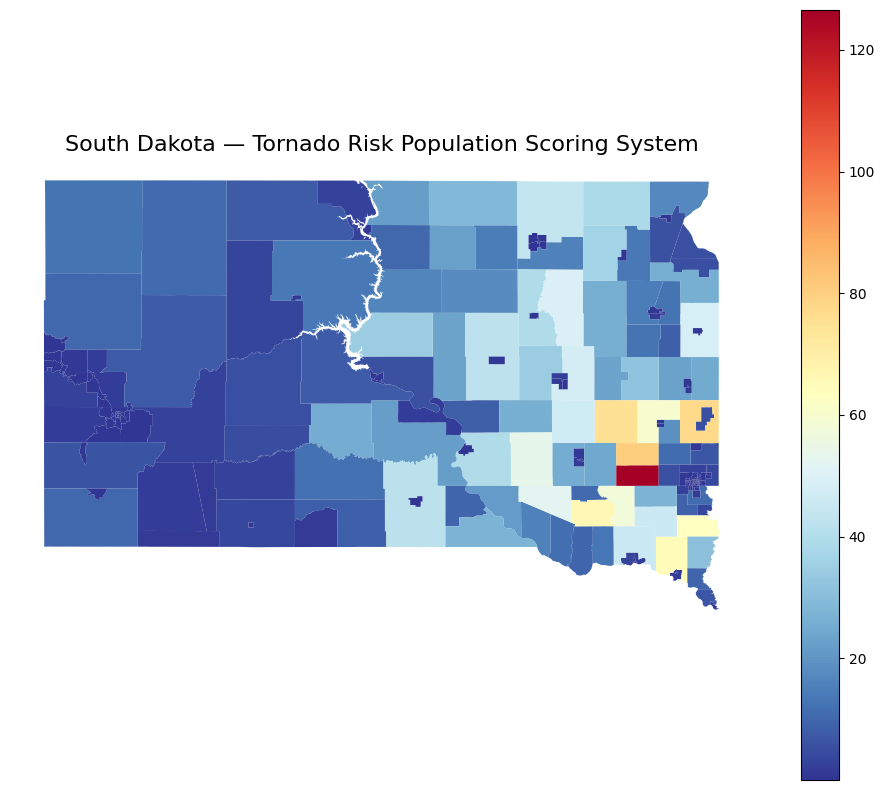

In [62]:
plot_map(
    sd_cleaned,
    column='risk_lvl_tnd_sd',
    cmap="RdYlBu_r",
    title="South Dakota — Tornado Risk Population Scoring System"
)


This section of code utilises the map plot tool to plot the tornado risks based on the scoring metric we created for the state of SD for comparison.

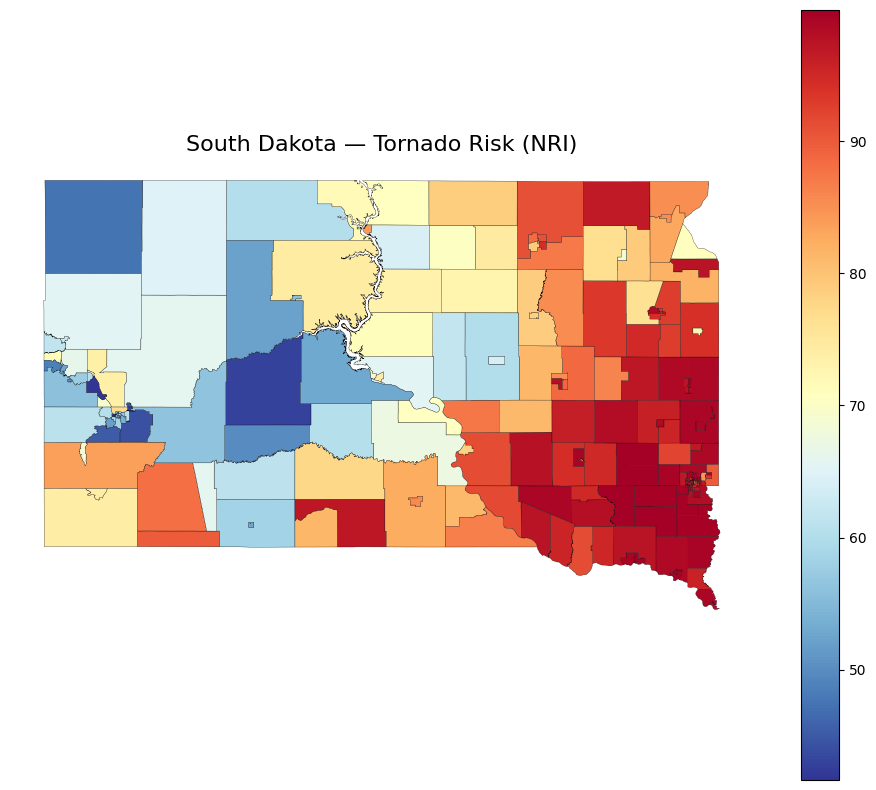

In [65]:
plot_map(
    sd_cleaned,
    column='TRND_RISKS',
    cmap="RdYlBu_r",
    title="South Dakota — Tornado Risk (NRI)"
)Z